# Classification with US Airline Sentiment Tweets

## Imports

In [1]:
'''General'''
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
'''Data'''
import pandas as pd
import numpy as np
"""Preprocessing"""
import re, string
import emoji
import nltk
from nltk.util import ngrams
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
import contractions
from collections import Counter
import spacy
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
'''Vectorization'''
from sklearn.feature_extraction.text import TfidfVectorizer
'''EDA'''
from nltk.probability import FreqDist
'''Visualization'''
import seaborn as sns
import matplotlib.pyplot as plt
# sns.set_palette("deep")
sns.set_theme(context='paper',
              style='white',
              font_scale=1.5,
              palette='viridis')

pd.set_option('display.max_columns', 200)

# Source Code

In [ ]:
#============================================================================
# Preprocessing
#============================================================================
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

nltk.download('wordnet')
nltk.download('omw-1.4')


STOP_WORDS = set(stopwords.words('english'))
# I noticed that the lemmatizer
# converted the 'us' to 'u'
# so I did an update
STOP_WORDS.update({"u", "us", "dm", "fleet", "fleek"})
# def preprocess(text):
#     """ Performs basic cleaning and optimization

#     Removes noise (HTML tags, mentions, urls, numbers etc)
#     Coverts emojis to text
#     Performs lowercasing

#     """
#     # Convert emojis to words
#     text = emoji.demojize(text)
#     # Remove @mentions
#     text = re.sub(r"@\w+", "", text)
#     # Remove only the '#' in hashtags
#     # split camel case words
#     # #WorstFlight -> 'worst flight'
#     text = re.sub(r"#(\w+)", lambda m: re.sub(r'([a-z])([A-Z])', r'\1 \2', m.group(1)), text)  # ← split hashtags
#     # Remove URLs
#     text = re.sub(r"https?://\S+|www\.\S+", "", text)
#     # Remove HTML tags
#     text = re.sub(r"<.*?>", "", text)
#     # Lowercase
#     text = text.lower()
#     # Keep only letters and underscores
#     # underscores kept so emoji words like angry_face stay intact
#     words = re.findall(r"[a-z_]+", text)
#     return " ".join(words)


SLANG_MAP = {
    "u": "you",
    "ur": "your",
    "r": "are",
    "b": "be",
    "pls": "please",
    "plz": "please",
    "thx": "thanks",
}
def preprocess(text):

    # Convert emojis to words
    text = emoji.demojize(text)
    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    # Remove @mentions
    text = re.sub(r"@\w+", "", text)
    # Remove RT (retweet) markers at the start or anywhere in text
    text = re.sub(r"(^RT\s+)|(\bRT\b)", "", text)
    # Split camelCase hashtags into separate words and remove the # symbol
    # e.g. #flightCancelled → flight Cancelled
    text = re.sub(r"#\w+", "", text)
    # text = re.sub(r"#(\w+)", lambda m: re.sub(r'([a-z])([A-Z])', r'\1 \2', m.group(1)), text)
    # Expand contractions (can't → cannot, won't → will not)
    text = contractions.fix(text)
    # Convert everything to lowercase
    text = text.lower()
    # Remove all punctuation characters (!, ?, ., :, etc.)
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove any remaining digits
    text = re.sub(r"\d+", "", text)
    # Collapse multiple spaces into one and strip leading/trailing spaces
    # Keep only letters and underscores
    # underscores kept so emoji words like angry_face stay intact
    text = re.sub(r"\s+", " ", text).strip()
    words = text.split()
    words = [SLANG_MAP.get(w, w) for w in words]
    words = re.findall(r"[a-z_]+", " ".join(words))  # ← use the updated words
    return " ".join(words)

def tokenize_and_clean(text):
    """Tokenize a document and remove stop words and punctuation
    """

    if isinstance(text, str):
        tokens = word_tokenize(text)
    else:
        tokens = text

    tokens = [t for t in tokens if t not in STOP_WORDS]
    return tokens

nlp = spacy.load("en_core_web_sm")

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def pos_tag_and_lemmatize(text):
    if isinstance(text, list):
        text = " ".join(text)
    pos_doc = nlp(text)

    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token.text, get_wordnet_pos(token.tag_)) for token in pos_doc]

    return tokens

def get_top_ngrams(all_tokens, n, top=10):

    bag = list(ngrams(all_tokens, n))

    return Counter(bag).most_common(top)

NORMALIZE_MAP = {}

def normalize_tokens(tokens):
    return [NORMALIZE_MAP.get(t, t) for t in tokens]

def remove_consecutive_dupes(tokens):
    return [t for i, t in enumerate(tokens) if i == 0 or t != tokens[i-1]]

# def get_top_ngrams(texts, n=2, top=10):
#     vec = CountVectorizer(ngram_range=(n, n)).fit(texts)
#     bag = vec.transform(texts)
#     freqs = bag.sum(axis=0).A1
#     words = vec.get_feature_names_out()
#     top_idx = freqs.argsort()[-top:][::-1]
#     return [(words[i], freqs[i]) for i in top_idx]

#============================================================================
#           ANN  SECTION:
#============================================================================
import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn
import torch.optim as optim
import copy

class EarlyStopping:
    """
    Early stops the training if validation loss doesn't improve after
    a given patience.

    Args:
        patience (int): The number of epochs the training loss has not
        improved
        min_delta (float): The minimum between train/test loss
    """
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > (self.best_loss - self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0


class EmbeddingsDataset(Dataset):
    """Provides a fundamental functionality for the implementation of a
    simple Dataset for word embeddings data. Each item is a single (feature, target)
    pair as a given index.

    Args:


    """
    def __init__(self, X, y, device):
        if not torch.is_tensor(X):
            X = torch.tensor(X, dtype=torch.float32)
        if not torch.is_tensor(y):
            y= torch.tensor(y, dtype=torch.long)

        self.X = X.to(device)
        self.y = y.to(device)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class MLP(nn.Module):
    """ Class implementation of a simple mutli-layer ANN with
        dynamic hidden layer input.

        Args:
            input_dim (int): Size of the input features.
            hidden_layers (list or int): List containing the size of each hidden layer,
            dropout_prob(float): Probability of dropping out neurons after each hidden layer.
    """

    def __init__(self, input_dim, hidden_layers, dropout_prob=0.2):
        super(MLP, self).__init__()
        layers = []
        in_features = input_dim

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(in_features, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=dropout_prob))
            in_features = hidden_size

        #Output layer
        layers.append(nn.Linear(in_features, 3))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    epochs,
    patience=5):
    """Function that performs the training of the neural network

    Args:
        model (nn.Module): The instance of the neural network model to be trained.
        train_loader (DataLoader): The DataLoader object tha provides the batches
          of the X and the y.
        test_loader (DataLoader): The DataLoader object that provides the batches
          of the testing X and y.
        criterion (callable): The optimization criterion.
        optimizer (torch.optim.Optimizer): The optimizer used during training.
        epochs (int): The number of training epochs to be performed.
        patience(int): The number of epochs to run before early stopping.

    Returns:
        model (torch.nn.Module): the trained model
        train_loss (List[float]): Training loss for each epoch.
        train_acc(List[float]): Training model accuracy
        test_loss (List[float]): Test loss for each epoch.
        test_acc (List[float]): Testing accuracy for each epoch.
        test_predictions (List[float]): All the test predictions.
    """
    train_loss = []
    train_acc = []
    test_loss = []
    test_acc = []
    test_predictions = []

    # Initialize early stopping
    early_stopping = EarlyStopping(patience=patience, min_delta=0.0001)
    # Initialize best model
    best_model_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        # Training phase
        # Training mode
        model.train()
        # Accumulators Initialization
        total_loss = 0.0
        correct_preds = 0
        total_samples = 0

        # Loop through batches of the train loader
        for X_batch, Y_batch in train_loader:
            #Set gradient vector to zero
            optimizer.zero_grad()

            preds = model(X_batch)

            # Loss computation
            loss = criterion(preds, Y_batch)

            # Backward pass
            loss.backward()

            # Update model parameters
            optimizer.step()

            total_loss += loss.item() * X_batch.size(0)

            # Number of correct prediction
            _, predicted = torch.max(preds, dim=1)
            correct_preds += (predicted == Y_batch).sum().item()
            total_samples += Y_batch.size(0)

        avg_train_loss = total_loss / len(train_loader.dataset)
        epoch_train_acc = correct_preds / total_samples

        # Validation
        avg_test_loss, avg_test_acc, all_test_predictions = test_model(model, test_loader, criterion)

        train_loss.append(avg_train_loss)
        train_acc.append(epoch_train_acc)
        test_loss.append(avg_test_loss)
        test_acc.append(avg_test_acc)
        test_predictions.append(all_test_predictions)

        print(
            f"Epoch [{epoch+1}/{epochs}], \n",
            f"Train Loss: {avg_train_loss:>10.6f} |",
            f"Train Acc:  {epoch_train_acc:>10.6f}\n",
            f"Test Loss:  {avg_test_loss:>10.6f} | ",
            f"Test Acc:   {avg_test_acc:>10.6f}"
        )

        # Save best model when test loss improves
        if early_stopping.best_loss is None or avg_test_loss < early_stopping.best_loss:
            best_model_state = copy.deepcopy(model.state_dict())
            print("Model improved.!")

        # Check early stopping
        early_stopping(avg_test_loss)
        if early_stopping.early_stop:
            print(f"Early stopping triggered at epoch {epoch+1}.")
            break

        # Restore best weights
        model.load_state_dict(best_model_state)
    return model, train_loss, train_acc, test_loss, test_acc, test_predictions



def test_model(model, test_loader, criterion):
    """Function that performs the testing of a
    neural network model.

    Args:
        model(nn.Module): The instance of the trained neural network model
        to be evaluated
        test_loader (DataLoader): The DataLoader object that provide the batches.
        of testing feature vectors along with the corresponding target.
        criterion (callable): The optimization criterion.

    Returns:
        val_loss(float): The average loss generated from validation
        val_acc (float): The average test accuracy of the classification
        val_predictions (List[float]): All the model prediction generated
        during training.
    """

    # Initiate Testing
    model.eval()

    # # Init Lists
    all_test_predictions = []
    val_loss = 0.0
    correct_val_preds = 0
    val_samples = 0

    # Testing
    with torch.no_grad():
       # Loop over batches from the DataLoader
       for X_batch, Y_batch in test_loader:
           # Test Preds
           preds = model(X_batch)

           # Compute the current test loss
           loss = criterion(preds, Y_batch)

           # Accumulate the loss
           val_loss += loss.item() * X_batch.size(0)

           # Compute Accuracy
           _, predicted = torch.max(preds, dim=1)
           correct_val_preds += (predicted == Y_batch).sum().item()
           all_test_predictions.extend(predicted.cpu().tolist())
           val_samples += Y_batch.size(0)


    test_loss = val_loss / len(test_loader.dataset)
    test_acc = correct_val_preds / val_samples

    return test_loss, test_acc, all_test_predictions



def get_predictions(model, data_loader):
    """Function that returns all model predictions and
    respective target values.

    Args:
        model(nn.Module): The trained PyTorch model.
        test_loader (DataLoader): The DataLoader object that provides the batches.
                                  dataset split.

    Returns:
        all_preds (np.ndarray): All the model prediction generated during training.
        all_targets(np.ndarray): Numpy array storing the ground-truth targets.
    """

    # Initiate Testing
    model.eval()

    # # Init Lists
    all_preds = []
    all_targets = []

    # Testing
    with torch.no_grad():
       # Loop over batches from the DataLoader
       for X_batch, Y_batch in data_loader:
           # Test Preds
           preds = model(X_batch)

           # Compute Accuracy
           _, predicted = torch.max(preds, dim=1)
           all_preds.extend(predicted.cpu().numpy())
           all_targets.extend(Y_batch.cpu().numpy())

    return all_preds, all_targets



#==========================================================================
# ANN UTILITY CODE:
#==========================================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def plot_training_history(train_loss, test_loss):
    """"A function that plots the training and testing loss.

    Args:
    train_loss(List[float]): list storing the training loss values for each epoch.
    test_lossList[float]):  list storing the training MAE values for each epoch.

    """

    # 1) Plot Loss History
    plt.figure(figsize=(8,6))
    plt.plot(train_loss, label="Train Loss")
    plt.plot(test_loss, label="Test Loss")
    plt.title("Loss per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(color='gray', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()



# This function reports the names, shapes, and total count of learnable
# parameters in a PyTorch model.
def report_model_parameters(model):
    """"This function reports the names, shapes and total count
        learnable parameters in a Pytorch model.
    Args:
        model(nn.Module): The PyTorch neural network.

    """
    print("Model Parameters:")

    total_params = 0  # Counter for the total number of learnable parameters

    # Loop over all named parameters of the model
    for name, param in model.named_parameters():
        shape = tuple(param.shape)  # Get the shape as a tuple
        count = param.numel()       # Get the number of elements in the tensor
        total_params += count       # Accumulate total parameter count
        print(f"{name:40s} -> {shape}")

    print(f"\nTotal number of learnable parameters: {total_params}")

def report_validation_metrics(
    y_true,
    y_pred,
    labels,
    average='macro',
    case='Validation'
    ):
    """Computes and prints classification metrics for model evaluation.

    Args:
        y_true (array-like): Ground-truth class labels.
        y_pred (array-like): Predicted class labels from the model.
        labels (array-like): List of unique class labels (e.g., [0, 1, 2]).
        average (str): Averaging strategy for precision, recall, and F1.
            Options: 'micro', 'macro', 'weighted'. Default is 'macro'.
    """
    acc_score = accuracy_score(y_true, y_pred)
    prec_score = precision_score(y_true, y_pred, labels=labels, average=average)
    rec_score = recall_score(y_true, y_pred, labels=labels, average=average)
    fone_score = f1_score(y_true, y_pred, labels=labels, average=average)
    conf_matrix = confusion_matrix(y_true, y_pred, labels=labels)

    print(f"\n\n{case:-^40}")
    print(f"\nAcuuracy Score:    {acc_score:.4f}")
    print(f"\nPrecision Score: {prec_score:.4f}")
    print(f"\nRecall Score:    {rec_score:.4f}")
    print(f"\nF1 Score:        {fone_score:.4f}")
    print("\nConfusion Matrix:\n")
    print(conf_matrix)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\alexm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\alexm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\alexm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\alexm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\alexm\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Data Preprocessing & EDA

In [3]:
filepath = "../data/01_raw/Tweets.csv"

tweets_df = pd.read_csv(filepath)
tweets_df.head(20)

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)
5,570300767074181121,negative,1.0000,Can't Tell,0.6842,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica seriously would pay $30 a fligh...,NaN,2015-02-24 11:14:33 -0800,NaN,Pacific Time (US & Canada)
6,570300616901320704,positive,0.6745,NaN,0.0000,Virgin America,NaN,cjmcginnis,NaN,0,"@VirginAmerica yes, nearly every time I fly VX...",NaN,2015-02-24 11:13:57 -0800,San Francisco CA,Pacific Time (US & Canada)
7,570300248553349120,neutral,0.6340,NaN,NaN,Virgin America,NaN,pilot,NaN,0,@VirginAmerica Really missed a prime opportuni...,NaN,2015-02-24 11:12:29 -0800,Los Angeles,Pacific Time (US & Canada)
8,570299953286942721,positive,0.6559,NaN,NaN,Virgin America,NaN,dhepburn,NaN,0,"@virginamerica Well, I didn't…but NOW I DO! :-D",NaN,2015-02-24 11:11:19 -0800,San Diego,Pacific Time (US & Canada)
9,570295459631263746,positive,1.0000,NaN,NaN,Virgin America,NaN,YupitsTate,NaN,0,"@VirginAmerica it was amazing, and arrived an ...",NaN,2015-02-24 10:53:27 -0800,Los Angeles,Eastern Time (US & Canada)


In [4]:
# Verify it's actually raw
print(tweets_df['text'].iloc[129])
# Should show: "@SomeAirline is flight cancelled #Flightled..."

@VirginAmerica is flight 882 Cancelled Flightled and what do I do if it is?


In [5]:
print(tweets_df.columns)

tweets_df = tweets_df[['airline_sentiment', 'text']].copy()

tweets_df.head(10)
print('Info')
print(tweets_df.info())
print('\nMissing Values')
print(tweets_df.isna().sum())
print(tweets_df['text'].sample(10))

print('\nSample tweets')
print("Text 1:", tweets_df['text'].iloc[18])
print("Text 2:", tweets_df['text'].iloc[100])
print("Text 3:", tweets_df['text'].iloc[200])

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')
Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   airline_sentiment  14640 non-null  object
 1   text               14640 non-null  object
dtypes: object(2)
memory usage: 228.9+ KB
None

Missing Values
airline_sentiment    0
text                 0
dtype: int64
1674     @united - Plane came in with broken seat.  Rat...
12132    @AmericanAir AND they Cancelled Flighted my fl...
7822                            @JetBlue yesterday's deal?
3534     @united  4348 soon going to have more wait tim...
2749     @u

In [6]:
tweets_df['text'] = tweets_df['text'].apply(preprocess)
print(tweets_df['text'].iloc[18])
tweets_df['tokens'] = tweets_df['text'].apply(tokenize_and_clean)
print(tweets_df['tokens'].sample(5))
tweets_df['tokens'] = tweets_df['tokens'].apply(pos_tag_and_lemmatize)
print(tweets_df['tokens'].iloc[10])

i redheart flying smilingfacethumbsup
8941     [hopefully, next, time, send, future, itinerar...
10267    [first, available, flight, tuesday, flight, to...
7876     [thanks, including, tour, pack, winter, coat, ...
2181                [tell, least, going, cover, room, get]
1859     [broken, light, mins, get, bridge, gate, airpl...
Name: tokens, dtype: object
['know', 'suicide', 'second', 'lead', 'death', 'among', 'teen']


### EDA

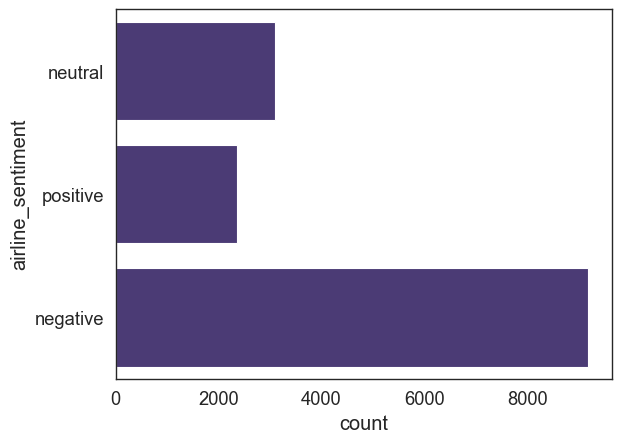

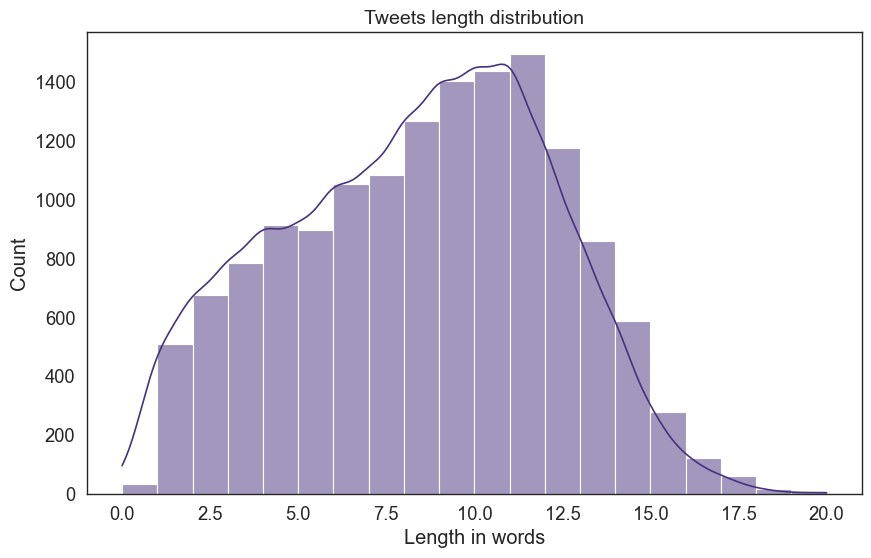

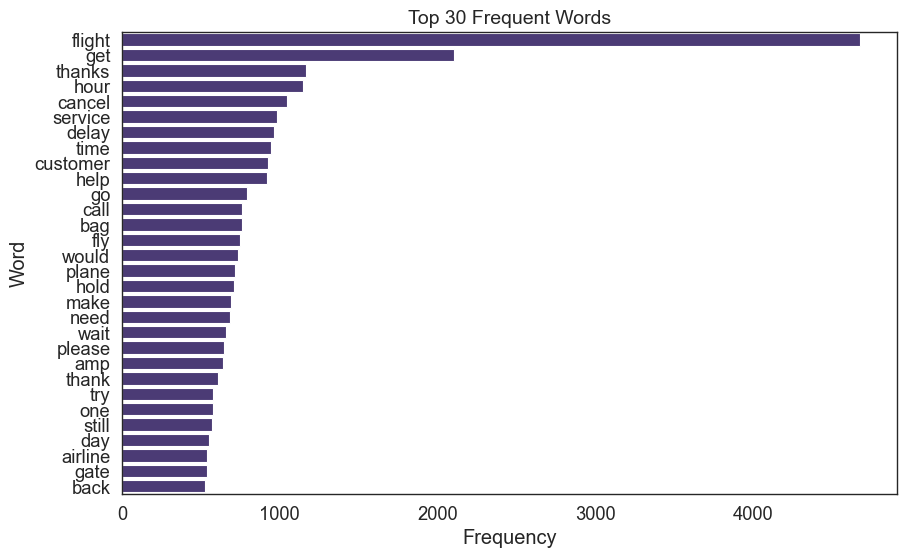

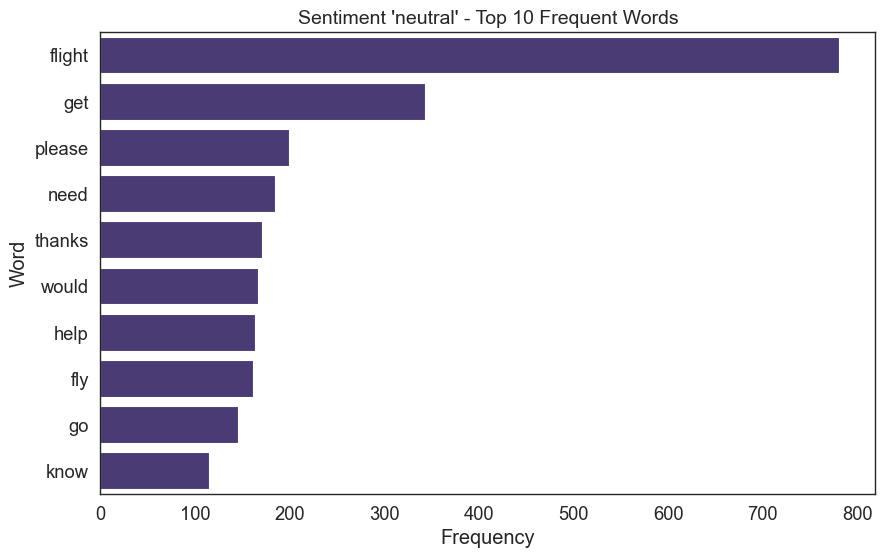

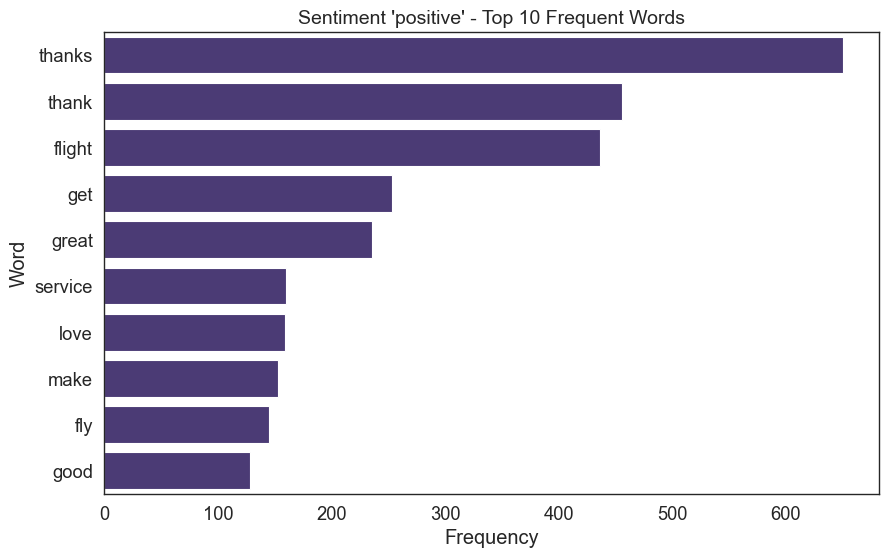

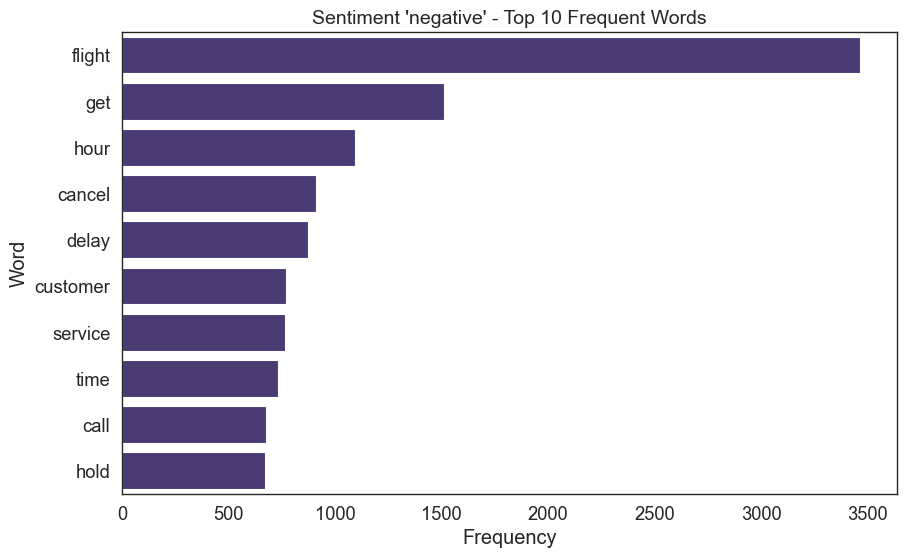

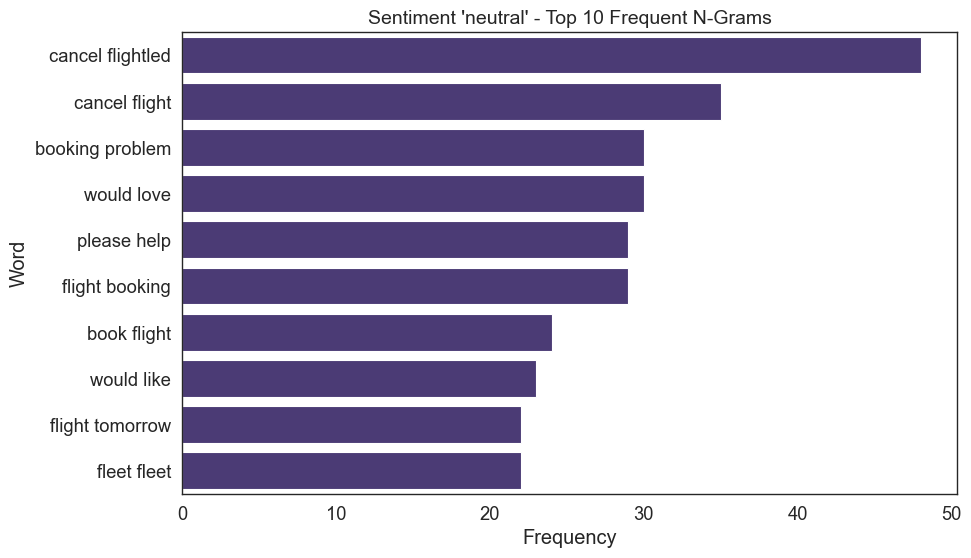

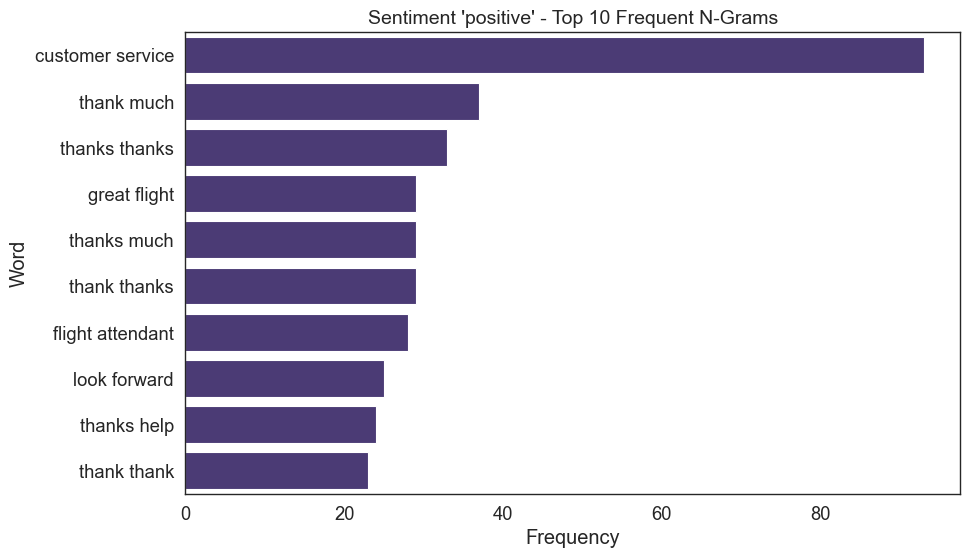

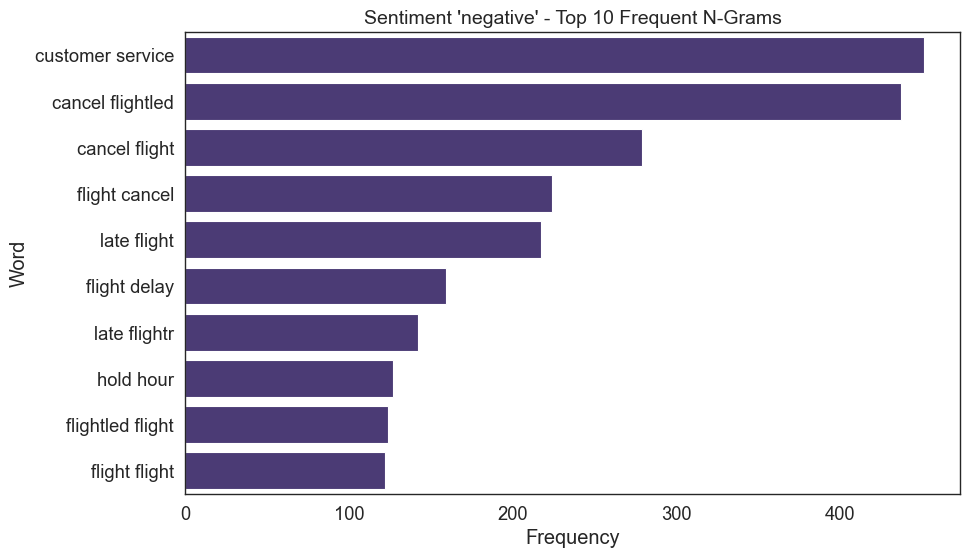

In [7]:
# target analysis
sns.countplot(data=tweets_df, y='airline_sentiment')

tweets_length = pd.DataFrame()
tweets_length['Length'] = tweets_df['tokens'].apply(len)


plt.figure(figsize=(10, 6))
sns.histplot(tweets_length, x='Length', bins=20, kde=True)
plt.title("Tweets length distribution", fontsize=14)
plt.xlabel("Length in words")
plt.show()

num_words = 30
all_tokens = [token for tokens in tweets_df['tokens'] for token in tokens]
fdist = FreqDist(all_tokens)
top_words = fdist.most_common(num_words)


df_top = pd.DataFrame(top_words, columns=['word', 'count'])

plt.figure(figsize=(10, 6))
sns.barplot(data=df_top, x='count', y='word')
plt.title(f"Top {num_words} Frequent Words", fontsize=14)
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()
top_ten_dict = {}
n_top_words = 10
top_ngrams_dict = {}

# Top words | Top ngrams per sentiment
for sentiment in tweets_df['airline_sentiment'].unique():
    subset_by_sentiment = tweets_df['tokens'].loc[tweets_df['airline_sentiment'] == sentiment]
    subset_tokens = [token for tokens in subset_by_sentiment for token in tokens]
    # subset_tokens
    top_ngrams = get_top_ngrams(subset_tokens, n=2, top=n_top_words)
    fdist_by_sentiment = FreqDist(subset_tokens)
    top_words = fdist_by_sentiment.most_common(n_top_words)
    top_ten_dict[sentiment] = pd.DataFrame(top_words, columns=['word', 'count'])
    top_ngrams_dict[sentiment] = pd.DataFrame(top_ngrams, columns=['word', 'count'])


#Plot
for sentiment, top_df in top_ten_dict.items():
    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_df, x='count', y='word')
    plt.title(f"Sentiment '{sentiment}' - Top {n_top_words} Frequent Words", fontsize=14)
    plt.xlabel("Frequency")
    plt.ylabel("Word")
    plt.show()

for sentiment, top_df in top_ngrams_dict.items():
    top_df['word'] = top_df['word'].apply(lambda x: " ".join(x))
    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_df, x='count', y='word')
    plt.title(f"Sentiment '{sentiment}' - Top {n_top_words} Frequent N-Grams", fontsize=14)
    plt.xlabel("Frequency")
    plt.ylabel("Word")
    plt.show()

In the 'top word' plots we can observe the following:
- 'flight' is the most frequent word overall and among the top for each sentiment
- 'thank' and 'thanks' was not preprocessed well with the POS and Lemmatization pipeline
- A frequent word seems to be the 'u' and 'dm' which correspond to slang words


I will further patch the preprocessing by 
- further searching for slang words, 
- replacing them
- remove new stopwords


The 'flight' is the most common word among all three sentiments. If another 
vectorizer except 'TF-IDF' will be use the the word must be deleted.
TF-IDF penalizes the common words, so in this case it will be an issue in the 
analysis. 

In [10]:
NORMALIZE_MAP = {
    "thanks": "thank",
    "flightled": "flight",
    "flightr": "flight",
    "flighted": "flight",
}

tweets_df['tokens'] = tweets_df['tokens'].apply(normalize_tokens)
tweets_df['tokens'] = tweets_df['tokens'].apply(remove_consecutive_dupes)

In [11]:
# Top words | Top ngrams per sentiment
for sentiment in tweets_df['airline_sentiment'].unique():
    subset_by_sentiment = tweets_df['tokens'].loc[tweets_df['airline_sentiment'] == sentiment]
    subset_tokens = [token for tokens in subset_by_sentiment for token in tokens]
    # subset_tokens
    top_ngrams = get_top_ngrams(subset_tokens, n=2, top=n_top_words)
    fdist_by_sentiment = FreqDist(subset_tokens)
    top_words = fdist_by_sentiment.most_common(n_top_words)
    top_ten_dict[sentiment] = pd.DataFrame(top_words, columns=['word', 'count'])
    top_ngrams_dict[sentiment] = pd.DataFrame(top_ngrams, columns=['word', 'count'])

top_ten_dict, top_ngrams_dict

({'neutral':      word  count
  0  flight    830
  1     get    339
  2   thank    241
  3  please    193
  4    need    184
  5   would    166
  6    help    163
  7     fly    160
  8      go    144
  9    know    115,
  'positive':        word  count
  0     thank   1094
  1    flight    443
  2       get    253
  3     great    236
  4   service    160
  5      love    157
  6      make    152
  7       fly    145
  8      good    128
  9  customer    122,
  'negative':        word  count
  0    flight   3854
  1       get   1506
  2      hour   1090
  3    cancel    913
  4     delay    869
  5  customer    770
  6   service    762
  7      time    732
  8      hold    673
  9      call    672},
 {'neutral':                  word  count
  0    (cancel, flight)     88
  1  (booking, problem)     30
  2       (would, love)     30
  3      (please, help)     29
  4   (flight, booking)     29
  5  (flight, tomorrow)     27
  6      (book, flight)     24
  7       (would, like)     23


### Train Test Split

In [12]:
le_ann = LabelEncoder()
tweets_df['label'] = le_ann.fit_transform(tweets_df['airline_sentiment'])


#Rejoin tokinized words
tweets_df['text_clean'] = tweets_df['tokens'].apply(lambda t: " ".join(t))


# Split Train, Test
X_train, X_test, y_train, y_test = train_test_split(
    tweets_df['text_clean'], tweets_df['label'],
    test_size=0.2,
    random_state=42,
    stratify=tweets_df['label']
)

# Split Train, Val
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size = 0.125, random_state=42
)


### Vectorization

For the vectorization of the text I will use the TF-IDF method. The decision is based on the following reasons:
1. The simplicity of use (no external dependencies, tweets does not need normalization)
2. Texts are short (10 words) and TF-IDF will work better here

In [92]:
n_vec_features = 6000
tfidf_vectorizer = TfidfVectorizer(max_features=n_vec_features, ngram_range=(1,2))

X_train_vec = tfidf_vectorizer.fit_transform(X_train).toarray()
X_test_vec = tfidf_vectorizer.transform(X_test).toarray()
X_val_vec = tfidf_vectorizer.transform(X_val).toarray()


In [93]:
y_train_vec = np.array(y_train, dtype=np.float32)
y_test_vec = np.array(y_test, dtype=np.float32)
y_val_vec = np.array(y_val, dtype=np.float32)

In [94]:
print("X train shape: ", X_train_vec.shape)
print("X test shape:  ", X_test_vec.shape)
print("X val shape:   ", X_val_vec.shape)


print("y train shape: ", y_train.shape)
print("y test shape:  ", y_test.shape)
print("y val shape:   ", y_val.shape)

X train shape:  (10248, 6000)
X test shape:   (2928, 6000)
X val shape:    (1464, 6000)
y train shape:  (10248,)
y test shape:   (2928,)
y val shape:    (1464,)


## Logistic Regression - Baseline

In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Train
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_vec, y_train)

# Predict on test
lr_preds = lr_model.predict(X_test_vec)

# Evaluate
print(classification_report(y_test, lr_preds,labels=[0,1,2], target_names=['Negative', 'Neutral', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.79      0.94      0.86      1835
     Neutral       0.65      0.45      0.53       620
    Positive       0.79      0.56      0.66       473

    accuracy                           0.77      2928
   macro avg       0.74      0.65      0.68      2928
weighted avg       0.76      0.77      0.76      2928



## Analysis with DL

Epoch [1/200], 
 Train Loss:   1.090285 | Train Acc:    0.471995
 Test Loss:    1.078906 |  Test Acc:     0.636612
Model improved.!
Epoch [2/200], 
 Train Loss:   1.063074 | Train Acc:    0.625683
 Test Loss:    1.039190 |  Test Acc:     0.636612
Model improved.!
Epoch [3/200], 
 Train Loss:   1.010323 | Train Acc:    0.625585
 Test Loss:    0.966804 |  Test Acc:     0.636612
Model improved.!
Epoch [4/200], 
 Train Loss:   0.926341 | Train Acc:    0.625585
 Test Loss:    0.874032 |  Test Acc:     0.636612
Model improved.!
Epoch [5/200], 
 Train Loss:   0.846947 | Train Acc:    0.625585
 Test Loss:    0.816073 |  Test Acc:     0.636612
Model improved.!
Epoch [6/200], 
 Train Loss:   0.801261 | Train Acc:    0.625585
 Test Loss:    0.784001 |  Test Acc:     0.636612
Model improved.!
Epoch [7/200], 
 Train Loss:   0.763079 | Train Acc:    0.628708
 Test Loss:    0.753652 |  Test Acc:     0.650273
Model improved.!
Epoch [8/200], 
 Train Loss:   0.724966 | Train Acc:    0.644321
 Test Loss:

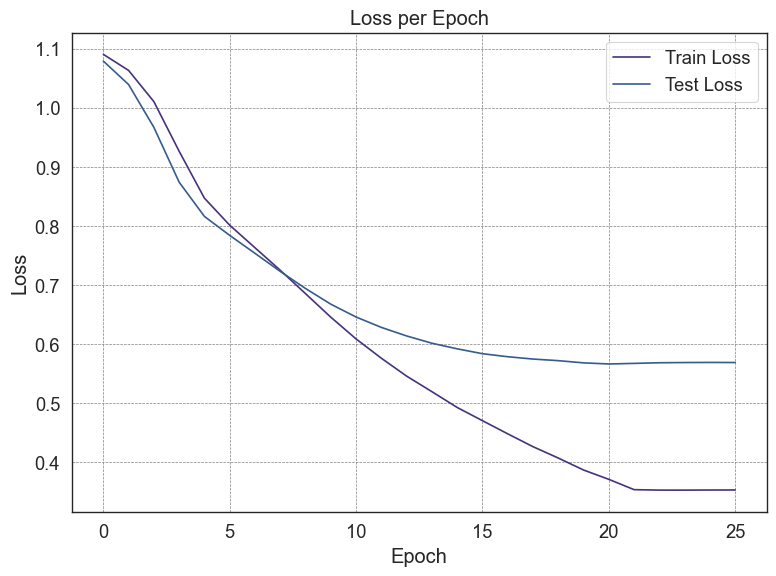

Model Parameters:
network.0.weight                         -> (256, 6000)
network.0.bias                           -> (256,)
network.3.weight                         -> (128, 256)
network.3.bias                           -> (128,)
network.6.weight                         -> (3, 128)
network.6.bias                           -> (3,)

Total number of learnable parameters: 1569539


-------------Validation Set-------------

Acuuracy Score:    0.7766

Precision Score: 0.7305

Recall Score:    0.6691

F1 Score:        0.6938

Confusion Matrix:

[[851  67  14]
 [132 147  26]
 [ 55  33 139]]


----------------Test Set----------------

Acuuracy Score:    0.7797

Precision Score: 0.7388

Recall Score:    0.6774

F1 Score:        0.7019

Confusion Matrix:

[[1675  129   31]
 [ 242  331   47]
 [ 115   81  277]]


In [ ]:
# =============================================================================
# Create Datasets & DataLoaders
# =============================================================================

device = 'cpu'

torch.manual_seed(42)

batch_size = 128

train_dataset = EmbeddingsDataset(X_train_vec, y_train_vec, device=device)
test_dataset = EmbeddingsDataset(X_test_vec, y_test_vec, device=device)
val_dataset = EmbeddingsDataset(X_val_vec, y_val_vec, device=device)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# =============================================================================
# Model definition
# =============================================================================

# Dimensionality of the input features
input_dim = X_train_vec.shape[1]

# Number of neurons per hidden layer
hidden_layers = [256, 128]

model = MLP(input_dim, hidden_layers, dropout_prob=0.2).to(device)


# =============================================================================
# Loss and Optimizer Definition
# =============================================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

# =============================================================================
# Model Training and Testing
# =============================================================================

# Number of training epochs
epochs = 200

# Actual training
model, train_loss, train_acc, test_loss, test_acc, train_test_predictions = train_model(model,
                                                                                        train_loader,
                                                                                        val_loader,
                                                                                        criterion,
                                                                                        optimizer,
                                                                                        epochs,
                                                                                        patience=5 )
# Plot the training history
plot_training_history(train_loss, test_loss)

# Get predictions for the training set
test_preds, test_actuals = get_predictions(model, test_loader)

# Get prediction for the test set
val_preds, val_actuals = get_predictions(model, val_loader)

# Network Parameters
report_model_parameters(model)

# Validation metrics of
report_validation_metrics(val_actuals, val_preds, labels=[0, 1, 2] , case='Validation Set')
report_validation_metrics(test_actuals, test_preds, labels=[0, 1, 2] , case='Test Set')


